# Spring 2026 Data Scratch 

In [22]:
import pandas as pd 
import matplotlib.pyplot as plt 
import os 
import math 

In [2]:
pnc_data = os.path.join("combined_data", "pnc_data.csv")
payload_data = os.path.join("combined_data", "payload_data.csv")


In [3]:
pnc = pd.read_csv(pnc_data)

display(pnc.head())
display(pnc.columns)

,header,uptime,id,length,temp_data,rtc_time,bmeTemp,bmePres,bmeHum,bmeGas,...,gpsBuff,gpsLat,gpsLong,gpsAlt,gpsVelN,gpsVelE,gpsVelD,gpsHacc,gpsVacc,checksum
0,3735931646,8810.0,0.0,87.0,32.287949,1.774688e+09,28.423706,96971.0,15.164077,5684.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,119.0
1,3735931646,9831.0,0.0,87.0,32.756092,1.774688e+09,28.466309,96970.0,15.131461,5684.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-6.0
2,3735931646,10865.0,0.0,87.0,34.160488,1.774688e+09,28.509226,96969.0,15.069174,5684.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0
3,3735931646,11865.0,0.0,87.0,32.756092,1.774688e+09,28.550262,96968.0,15.031548,5684.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-48.0
4,3735931646,12529.0,0.0,87.0,33.224236,1.774688e+09,28.636410,96968.0,15.005961,5684.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62.0


Index(['header', 'uptime', 'id', 'length', 'temp_data', 'rtc_time', 'bmeTemp',
       'bmePres', 'bmeHum', 'bmeGas', 'inaCurrent', 'inaVoltage', 'inaPower',
       'gpsTime', 'gpsFix', 'gpsFixOk', 'gpsSiv', 'gpsBuff', 'gpsLat',
       'gpsLong', 'gpsAlt', 'gpsVelN', 'gpsVelE', 'gpsVelD', 'gpsHacc',
       'gpsVacc', 'checksum'],
      dtype='str')

In [14]:
pay = pd.read_csv(payload_data)

display(pay.head())
display(pay.columns)
display(pay["PicoTemp Temp (C)"].dtype)

,Millis,PicoTemp Temp (C),ICM20948 AccX (g),ICM20948 AccY (g),ICM20948 AccZ (g),ICM20948 GyroX (deg/s),ICM20948 GyroY (deg/s),ICM20948 GyroZ (deg/s),ICM20948 MagX (uT),ICM20948 MagY (uT),...,ENS160_O TVOC (ppb),ENS160_O eCO2 (ppm),BMP390_O Temp (C),BMP390_O Pressure (Pa),BMP390_O Altitude (m),TMP117_O Temp_O (C),SHTC3_O Temp (C),SHTC3_O Rel Hum (%),Ozone Conc (ppb),AnalogTemp ADC_Read
0,267,NaN,-1.374272,-0.248997,9.653421,0.041505,0.088331,-0.085670,31.350000,39.150002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,780,NaN,-1.628057,-0.239420,9.567230,0.047890,0.001064,-0.021817,31.350000,38.700001,...,NaN,NaN,NaN,NaN,NaN,32.031250,31.879999,16.180000,NaN,NaN
2,1677,24.329636,-2.145205,-0.205901,9.777920,-0.303304,-0.217634,-0.014899,37.650002,37.950001,...,NaN,NaN,NaN,NaN,NaN,32.031250,31.660000,16.100000,NaN,NaN
3,2677,NaN,-2.686294,-0.809240,9.691729,-0.199010,-0.420901,0.120790,39.900002,34.950001,...,NaN,NaN,NaN,NaN,NaN,31.867188,31.410000,16.190001,NaN,NaN
4,3575,26.202177,-1.628057,0.402226,9.811439,0.002661,-0.127707,-0.117065,37.650002,34.950001,...,NaN,NaN,NaN,NaN,NaN,31.554688,31.420000,16.250000,NaN,NaN


Index(['Millis', 'PicoTemp Temp (C)', 'ICM20948 AccX (g)', 'ICM20948 AccY (g)',
       'ICM20948 AccZ (g)', 'ICM20948 GyroX (deg/s)', 'ICM20948 GyroY (deg/s)',
       'ICM20948 GyroZ (deg/s)', 'ICM20948 MagX (uT)', 'ICM20948 MagY (uT)',
       'ICM20948 MagZ (uT)', 'ICM20948 Temp (C)', 'PCF8523 Year',
       'PCF8523 Month', 'PCF8523 Day', 'PCF8523 Hour', 'PCF8523 Minute',
       'PCF8523 Second', 'TMP117 Temp (C)', 'BME688 Temp (C)',
       'BME688 Pressure', 'BME688 Rel Hum (%)', 'BME688 Gas Resistance',
       'Geiger CPS', 'Geiger Dose (uSv/hr)', 'UV_Sensor_O UVA2 (nm)',
       'UV_Sensor_O UVB2 (nm)', 'UV_Sensor_O UVC2 (nm)', 'ENS160_O AQI',
       'ENS160_O TVOC (ppb)', 'ENS160_O eCO2 (ppm)', 'BMP390_O Temp (C)',
       'BMP390_O Pressure (Pa)', 'BMP390_O Altitude (m)',
       'TMP117_O Temp_O (C)', 'SHTC3_O Temp (C)', 'SHTC3_O Rel Hum (%)',
       'Ozone Conc (ppb)', 'AnalogTemp ADC_Read'],
      dtype='str')

dtype('float64')

In [17]:
pnc["minutes"] = pnc["uptime"] / 1000 / 60
pay["minutes"] = pay["Millis"] / 1000 / 60 

[]

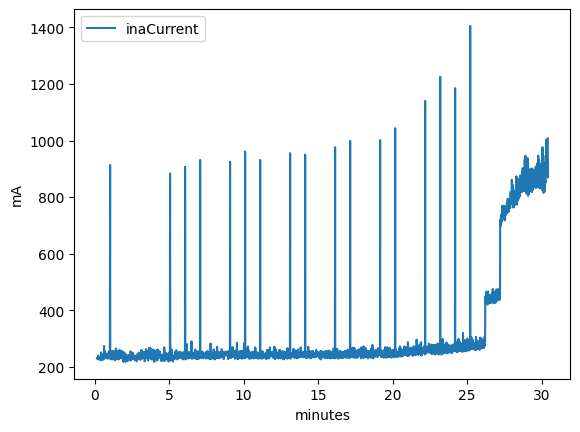

In [6]:
pnc.plot("minutes", 'inaCurrent')
plt.ylabel("mA")
plt.show()

[]

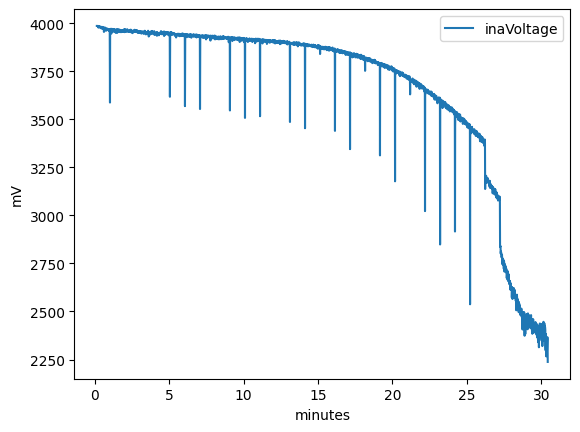

In [7]:
pnc.plot("minutes", 'inaVoltage')
plt.ylabel("mV")
plt.show()

[]

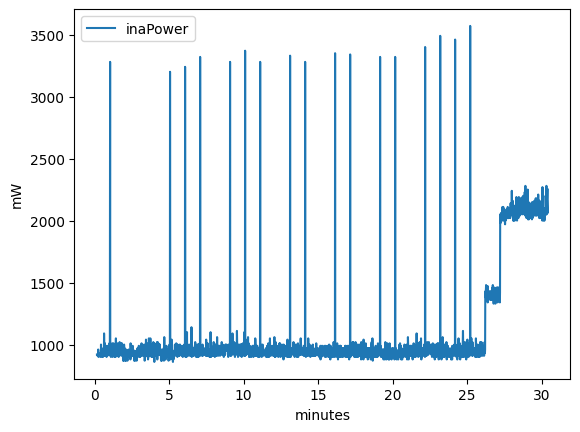

In [8]:
pnc.plot("minutes", 'inaPower')
plt.ylabel("mW")
plt.show()

[]

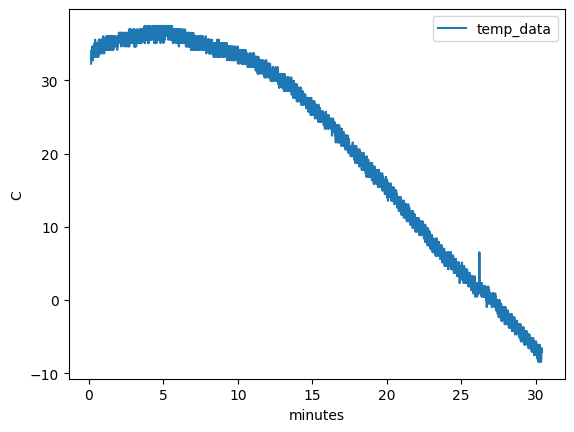

In [9]:
pnc.plot("minutes", 'temp_data')
plt.ylabel("C")
plt.show()

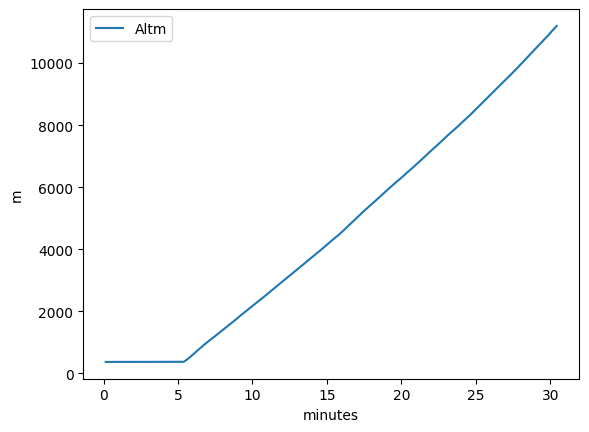

In [40]:
def pres_to_alt(pres):
    return 44330 * (1 - (pres / 101325)**(1/5.255))

pnc["Altm"] = pnc["bmePres"].apply(pres_to_alt)
pnc.plot("minutes", 'Altm')
plt.ylabel("m")
plt.show()

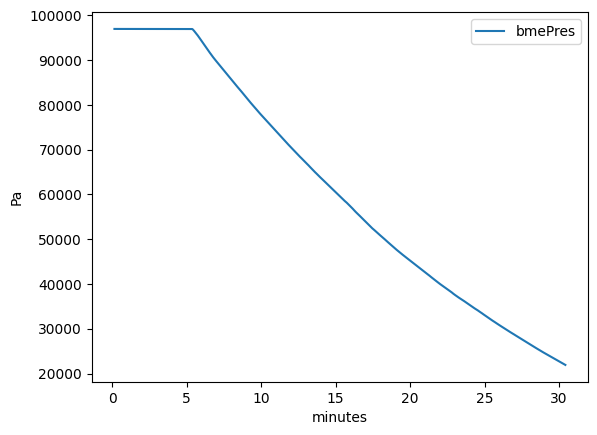

In [41]:
pnc.plot("minutes", 'bmePres')
plt.ylabel("Pa")
plt.show()

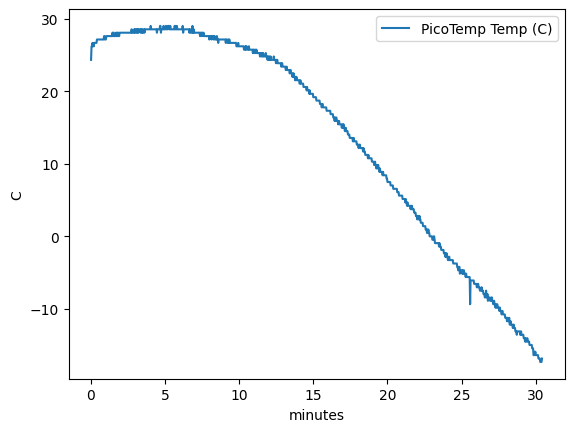

In [21]:
clean_temp = pay.dropna(subset=["minutes", "PicoTemp Temp (C)"])
clean_temp.plot("minutes", "PicoTemp Temp (C)")
plt.ylabel("C")
plt.show()

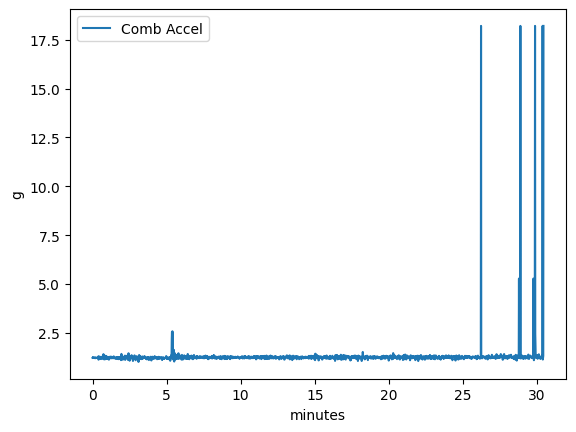

In [36]:
x = pay["ICM20948 AccX (g)"]
y = pay["ICM20948 AccY (g)"]
z = pay["ICM20948 AccZ (g)"]
Accel = []
for i in range(len(x)):
    Accel.append(math.sqrt(x[i]**2 + y[i]**2 + z[i]**2) / 8)
pay["Comb Accel"] = Accel

clean_imu = pay.dropna(subset=["minutes", "Comb Accel"])
clean_imu.plot("minutes", "Comb Accel")
plt.ylabel("g")
plt.show()